In [1]:
# from metalearning_benchmarks.line_sine1d_benchmark import LineSine1D
from metalearning_benchmarks.sinusoid1d_benchmark import Sinusoid1D

# from metalearning_benchmarks.linear1d_benchmark import Linear1D
import matplotlib.pyplot as plt
from torch.optim import AdamW

# Encoder: Aggregates context (X_ctx, Y_ctx) -> r
from sampling.masked.sampler import MaskedMetaNETSSampler
import numpy as np
import matplotlib.pyplot as plt
import torch
from sampling.masked.loader import get_meta_loader
from sampling.masked.train import train_meta_nets_final


benchmark = Sinusoid1D(
    n_task=128,  # number of tasks
    n_datapoints_per_task=64,  # number of evaluations per task
    output_noise=0.01,  # Gaussian noise with std-dev 0.01
    seed_task=0,
    seed_x=0,
    seed_noise=0,
)

Generating tasks: 100%|██████████| 128/128 [00:00<00:00, 223416.94it/s]


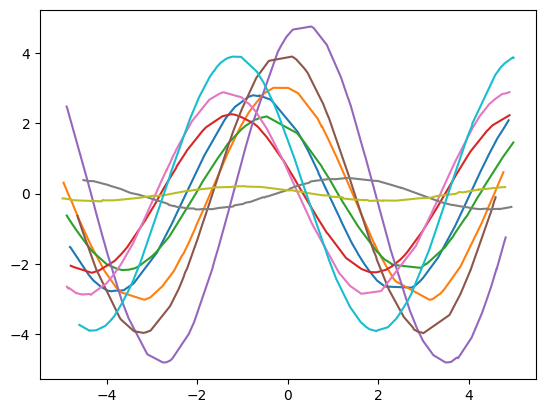

In [2]:
for i in range(10):
    task = benchmark.get_task_by_index(i)  # (128,1,1)

    x = task.x.squeeze()  # (128,)
    y = task.y.squeeze()  # (128,)

    indices = np.argsort(x)
    x = x[indices]
    y = y[indices]

    plt.plot(x, y)

plt.show()

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
loader = get_meta_loader(benchmark, batch_size=512, context_size=16)

In [5]:
from sampling.masked.models import SetDecoder
from sampling.masked.models_adaptive import ConvSetEncoder, MaskedSetEncoder


x_dim = 1
y_dim = 1
z_dim = 2
r_dim = 64
hidden_dim = 128
sigma = 0.1
epsilon = 3.0


# set_encoder = AttentionSetEncoder(
#     x_dim=x_dim, y_dim=y_dim, r_dim=r_dim, hidden_dim=hidden_dim
# ).to(device)
set_encoder = ConvSetEncoder(
    x_dim=x_dim, y_dim=y_dim, r_dim=r_dim, points_per_unit=64, grid_range=(-5.0, 5.0)
).to(device)

# MaskedSetEncoder(
#     x_dim=x_dim, y_dim=y_dim, r_dim=r_dim, hidden_dim=hidden_dim
# ).to(device)
set_decoder = SetDecoder(
    x_dim=x_dim, y_dim=y_dim, z_dim=z_dim, hidden_dim=hidden_dim
).to(device)

# Sampler: Manages Drift, F-Net, and Replay Buffer
# We pass the encoder/decoder so the sampler can compute internal energies
nets = MaskedMetaNETSSampler(
    set_encoder=set_encoder,
    set_decoder=set_decoder,
    z_dim=z_dim,
    r_dim=r_dim,
    hidden_dim=128,
    sigma=sigma,
    epsilon=epsilon,
).to(device)

In [6]:
lr_nets: float = 5e-4
lr_model: float = 5e-4

# OPT 1: Inference / Sampler Dynamics
# Trains the "How to Sample" components:
# - Drift & F-Net: Learn the transport dynamics.
# - Encoder: Learns to parameterize those dynamics based on data (x, y).
# Minimizes PINN Residual.
opt_nets = AdamW(nets.parameters(), lr=lr_nets)

# OPT 2: Generative Model
# Trains the "What is Likelihood" component:
# - Decoder: Maximizes p(y | x, z).
# Minimizes Reconstruction Error.
opt_model = AdamW(set_decoder.parameters(), lr=lr_model)

In [8]:
_ = train_meta_nets_final(
    device,
    loader,
    nets,
    set_encoder,
    set_decoder,
    opt_nets,
    opt_model,
    epochs=500,
    pinn_update_freq=3,
    train_decoder=True,
)

Starting Meta-Training...
Batch 1/1: Context Size = 10
Epoch 1: PINN=2377186.00, Recon=0.4700
Batch 1/1: Context Size = 3
Epoch 2: PINN=806401.31, Recon=0.3085
Batch 1/1: Context Size = 1
Epoch 3: PINN=151455.39, Recon=1.5305
Batch 1/1: Context Size = 2
Epoch 4: PINN=153869.83, Recon=0.4830
Batch 1/1: Context Size = 11
Epoch 5: PINN=1514991.88, Recon=0.5270
Batch 1/1: Context Size = 11
Epoch 6: PINN=2139523.50, Recon=0.4776
Batch 1/1: Context Size = 5
Epoch 7: PINN=676782.06, Recon=0.2379
Batch 1/1: Context Size = 3
Epoch 8: PINN=288653.06, Recon=0.2914
Batch 1/1: Context Size = 12
Epoch 9: PINN=3220550.50, Recon=0.5773
Batch 1/1: Context Size = 2
Epoch 10: PINN=180834.83, Recon=0.6229
Batch 1/1: Context Size = 10
Epoch 11: PINN=1218531.88, Recon=0.4949
Batch 1/1: Context Size = 4
Epoch 12: PINN=536645.75, Recon=0.2503
Batch 1/1: Context Size = 9
Epoch 13: PINN=1398838.75, Recon=0.4619
Batch 1/1: Context Size = 9
Epoch 14: PINN=1503734.25, Recon=0.4565
Batch 1/1: Context Size = 14
Epoc

KeyboardInterrupt: 

In [10]:
# save model
torch.save(set_encoder.state_dict(), "set_encoder.pt")
torch.save(set_decoder.state_dict(), "set_decoder.pt")
torch.save(nets.state_dict(), "nets.pt")

In [7]:
# load models
set_encoder.load_state_dict(torch.load("set_encoder.pt"))
set_decoder.load_state_dict(torch.load("set_decoder.pt"))
nets.load_state_dict(torch.load("nets.pt"))

<All keys matched successfully>

In [8]:
from sampling.masked.vis import create_tasks_from_loader, visualize_tasks_overview


ahh = create_tasks_from_loader(
    loader,
    set_encoder,
    set_decoder,
    device,
    n_tasks=20,
)

visualize_tasks_overview(*ahh)

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (64x65 and 3x128)

In [10]:
from sampling.masked.train import visualize_meta_results
from sampling.meta.vis import visualize_task_eval

eval_loader = get_meta_loader(benchmark, batch_size=1, context_size=3)

# 2. Fetch a single batch
# iter() creates an iterator, and next() grabs the first batch
batch_data = next(iter(eval_loader))

# Unpack the batch.
# Each tensor has shape: (Batch_Size, N_Points, Dim)
# e.g., (4, 10, 1) for context, (4, 128, 1) for target
x_ctx_batch, y_ctx_batch, x_tar_batch, y_tar_batch = batch_data

# 3. Select the first task in the batch (Index 0)
# We slice [0] to get shape (N_Points, Dim)
x_ctx_eval = x_ctx_batch[0].to(device)
y_ctx_eval = y_ctx_batch[0].to(device)
x_tar_eval = x_tar_batch[0].to(device)
y_tar_eval = y_tar_batch[0].to(device)

visualize_meta_results(
    nets,
    set_encoder,
    set_decoder,
    x_ctx_eval,
    y_ctx_eval,
    x_tar_eval,
    y_tar_eval,
    device,
    num_samples=512,
    save_path="eval_task_512.png",
)

TypeError: visualize_meta_results() missing 1 required positional argument: 'device'